# Task 3 — CLIP

## Setup

In [2]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import STL10

import clip


SEED = 42
BATCH_SIZE = 128

torch.manual_seed(SEED)
np.random.seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


RESULTS_DIR = Path("task3/results")
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 3.1 Zero-Shot Classification on STL-10

### Load CLIP

In [4]:
model, preprocess = clip.load(
    "ViT-B/32",
    device=device,
)

model.eval()

print("CLIP model loaded.")

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 147MiB/s]


CLIP model loaded.


### STL-10 Dataset

In [20]:
STL_ROOT = Path(
    "/kaggle/input/datasets/sohauvv/stl10-local"
)


class STL10Binary(Dataset):
    def __init__(self, root, split, transform=None):
        self.root = Path(root)
        self.transform = transform

        x_path = self.root / f"{split}_X.bin"
        y_path = self.root / f"{split}_y.bin"

        self.data = np.fromfile(
            x_path,
            dtype=np.uint8,
        )

        self.data = self.data.reshape(
            -1,
            3,
            96,
            96,
        )

        # STL-10 stores images in column-major order
        self.data = np.transpose(
            self.data,
            (0, 1, 3, 2),
        )

        self.labels = np.fromfile(
            y_path,
            dtype=np.uint8,
        ).astype(np.int64) - 1

        with open(
            self.root / "class_names.txt"
        ) as f:
            self.classes = [
                line.strip()
                for line in f
            ]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = np.transpose(
            self.data[idx],
            (1, 2, 0),
        )

        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        return image, int(self.labels[idx])

In [21]:
train_dataset = STL10Binary(
    STL_ROOT,
    split="train",
    transform=preprocess,
)

test_dataset = STL10Binary(
    STL_ROOT,
    split="test",
    transform=preprocess,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Train images: 5000
Test images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


### Prompt Strategies

In [22]:
class_names = train_dataset.classes


prompt_strategies = {
    "Class name": [
        class_name
        for class_name in class_names
    ],

    "Photo template": [
        f"a photo of a {class_name}"
        for class_name in class_names
    ],

    "Descriptive": [
        "a photo of an airplane flying in the sky",
        "a photo of a bird with feathers and wings",
        "a photo of a car driving on a road",
        "a photo of a domestic cat",
        "a photo of a deer in nature",
        "a photo of a domestic dog",
        "a photo of a horse",
        "a photo of a monkey",
        "a photo of a ship on the water",
        "a photo of a truck driving on a road",
    ],
}


for strategy, prompts in prompt_strategies.items():
    print(f"\n{strategy}:")

    for prompt in prompts:
        print(" ", prompt)


Class name:
  airplane
  bird
  car
  cat
  deer
  dog
  horse
  monkey
  ship
  truck

Photo template:
  a photo of a airplane
  a photo of a bird
  a photo of a car
  a photo of a cat
  a photo of a deer
  a photo of a dog
  a photo of a horse
  a photo of a monkey
  a photo of a ship
  a photo of a truck

Descriptive:
  a photo of an airplane flying in the sky
  a photo of a bird with feathers and wings
  a photo of a car driving on a road
  a photo of a domestic cat
  a photo of a deer in nature
  a photo of a domestic dog
  a photo of a horse
  a photo of a monkey
  a photo of a ship on the water
  a photo of a truck driving on a road


### Text Embeddings

In [23]:
def encode_prompts(prompts):
    text_tokens = clip.tokenize(
        prompts
    ).to(device)

    with torch.no_grad():
        text_features = model.encode_text(
            text_tokens
        )

    text_features = (
        text_features
        / text_features.norm(
            dim=-1,
            keepdim=True,
        )
    )

    return text_features


text_features_by_strategy = {
    strategy: encode_prompts(prompts)
    for strategy, prompts
    in prompt_strategies.items()
}


for strategy, features in (
    text_features_by_strategy.items()
):
    print(
        strategy,
        features.shape,
    )

Class name torch.Size([10, 512])
Photo template torch.Size([10, 512])
Descriptive torch.Size([10, 512])


### Zero-Shot Evaluation

In [24]:
correct = {
    strategy: 0
    for strategy in prompt_strategies
}

total = 0


model.eval()


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(device)


        image_features = model.encode_image(
            images
        )

        image_features = (
            image_features
            / image_features.norm(
                dim=-1,
                keepdim=True,
            )
        )


        for strategy, text_features in (
            text_features_by_strategy.items()
        ):
            similarities = (
                100.0
                * image_features
                @ text_features.T
            )

            predictions = similarities.argmax(
                dim=1
            )

            correct[strategy] += (
                predictions == labels
            ).sum().item()


        total += labels.size(0)

In [26]:
zero_shot_results = pd.DataFrame({
    "prompt_strategy": list(correct.keys()),
    "accuracy": [
        correct[strategy] / total
        for strategy in correct
    ],
})


zero_shot_results = (
    zero_shot_results
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("Images evaluated:", total)
print()
print(zero_shot_results)

Images evaluated: 8000

  prompt_strategy  accuracy
0  Photo template  0.973625
1      Class name  0.962625
2     Descriptive  0.933750


In [27]:
zero_shot_path = (
    RESULTS_DIR /
    "clip_zero_shot_results.csv"
)


zero_shot_results.to_csv(
    zero_shot_path,
    index=False,
)


print("Saved to:", zero_shot_path)

Saved to: task3/results/clip_zero_shot_results.csv


## 3.2 The Modality Gap

### Paired Image and Text Embeddings

In [28]:
NUM_GAP_SAMPLES = 500

rng = np.random.default_rng(SEED)

sample_indices = rng.choice(
    len(test_dataset),
    size=NUM_GAP_SAMPLES,
    replace=False,
)

sample_indices = set(
    sample_indices.tolist()
)


gap_image_features = []
gap_text_features = []
gap_labels = []

samples_collected = 0


# Use the best prompt strategy from 3.1
photo_text_features = (
    text_features_by_strategy["Photo template"]
)


with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(
        test_loader
    ):
        batch_start = batch_idx * BATCH_SIZE

        selected = [
            i
            for i in range(len(labels))
            if batch_start + i in sample_indices
        ]

        if not selected:
            continue


        selected_images = images[selected].to(
            device,
            non_blocking=True,
        )

        selected_labels = labels[selected].to(device)


        image_features = model.encode_image(
            selected_images
        )

        image_features = (
            image_features
            / image_features.norm(
                dim=-1,
                keepdim=True,
            )
        )


        # Each image gets the text embedding
        # corresponding to its ground-truth class
        text_features = photo_text_features[
            selected_labels
        ]


        gap_image_features.append(
            image_features.cpu()
        )

        gap_text_features.append(
            text_features.cpu()
        )

        gap_labels.append(
            selected_labels.cpu()
        )

        samples_collected += len(selected)


gap_image_features = torch.cat(
    gap_image_features
).numpy()

gap_text_features = torch.cat(
    gap_text_features
).numpy()

gap_labels = torch.cat(
    gap_labels
).numpy()


print(
    "Image embeddings:",
    gap_image_features.shape,
)

print(
    "Text embeddings:",
    gap_text_features.shape,
)

print(
    "Labels:",
    gap_labels.shape,
)

Image embeddings: (500, 512)
Text embeddings: (500, 512)
Labels: (500,)


### PCA Visualization

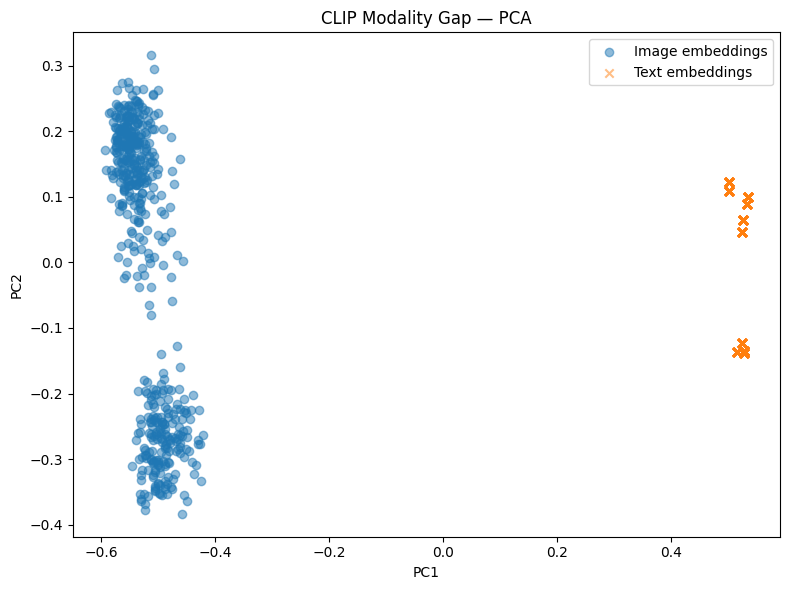

Saved to: task3/results/clip_modality_gap_pca.png


In [29]:
from sklearn.decomposition import PCA


combined_features = np.vstack([
    gap_image_features,
    gap_text_features,
])


pca = PCA(
    n_components=2,
    random_state=SEED,
)

pca_embedding = pca.fit_transform(
    combined_features
)


pca_images = pca_embedding[
    :NUM_GAP_SAMPLES
]

pca_text = pca_embedding[
    NUM_GAP_SAMPLES:
]


plt.figure(figsize=(8, 6))

plt.scatter(
    pca_images[:, 0],
    pca_images[:, 1],
    alpha=0.5,
    label="Image embeddings",
)

plt.scatter(
    pca_text[:, 0],
    pca_text[:, 1],
    alpha=0.5,
    marker="x",
    label="Text embeddings",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CLIP Modality Gap — PCA")
plt.legend()
plt.tight_layout()


pca_path = (
    RESULTS_DIR /
    "clip_modality_gap_pca.png"
)

plt.savefig(
    pca_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", pca_path)

### t-SNE Visualization

In [30]:
from sklearn.manifold import TSNE


tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
)


tsne_embedding = tsne.fit_transform(
    combined_features
)


tsne_images = tsne_embedding[
    :NUM_GAP_SAMPLES
]

tsne_text = tsne_embedding[
    NUM_GAP_SAMPLES:
]

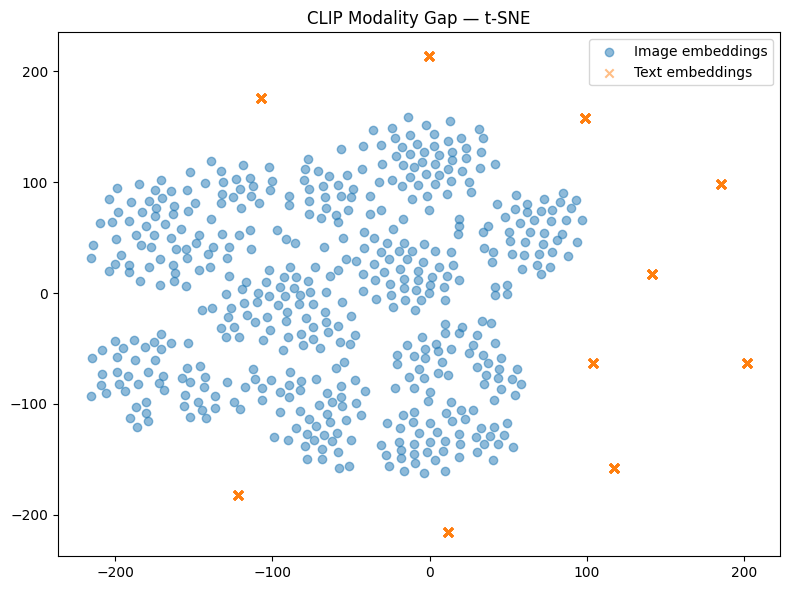

Saved to: task3/results/clip_modality_gap_tsne.png


In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tsne_images[:, 0],
    tsne_images[:, 1],
    alpha=0.5,
    label="Image embeddings",
)

plt.scatter(
    tsne_text[:, 0],
    tsne_text[:, 1],
    alpha=0.5,
    marker="x",
    label="Text embeddings",
)

plt.title("CLIP Modality Gap — t-SNE")
plt.legend()
plt.tight_layout()


tsne_path = (
    RESULTS_DIR /
    "clip_modality_gap_tsne.png"
)

plt.savefig(
    tsne_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", tsne_path)

### Quantifying the Modality Gap

In [33]:
image_centroid = gap_image_features.mean(
    axis=0
)

text_centroid = gap_text_features.mean(
    axis=0
)


centroid_cosine_similarity = (
    F.cosine_similarity(
        torch.tensor(image_centroid).unsqueeze(0),
        torch.tensor(text_centroid).unsqueeze(0),
    ).item()
)


paired_cosine_similarity = np.sum(
    gap_image_features * gap_text_features,
    axis=1,
)


print(
    "Image/Text centroid cosine similarity:",
    f"{centroid_cosine_similarity:.4f}",
)

print(
    "Mean paired image-text cosine similarity:",
    f"{paired_cosine_similarity.mean():.4f}",
)

print(
    "Std paired image-text cosine similarity:",
    f"{paired_cosine_similarity.std():.4f}",
)

Image/Text centroid cosine similarity: 0.2720
Mean paired image-text cosine similarity: 0.2661
Std paired image-text cosine similarity: 0.0211


### Class-Aware Modality Visualization

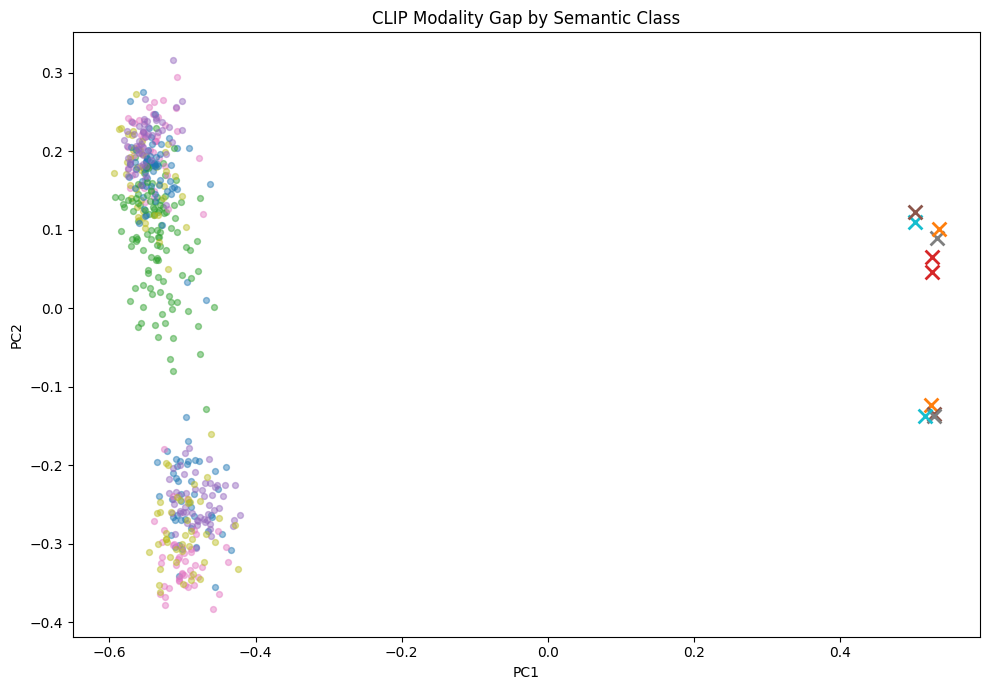

Saved to: task3/results/clip_modality_gap_by_class.png


In [43]:
class_names = train_dataset.classes

plt.figure(figsize=(10, 7))

for class_idx, class_name in enumerate(class_names):
    image_mask = gap_labels == class_idx

    plt.scatter(
        pca_images[image_mask, 0],
        pca_images[image_mask, 1],
        s=18,
        alpha=0.45,
        label=f"{class_name} images",
    )

    # All text embeddings for a class are identical,
    # so plot only one representative point.
    text_point = pca_text[image_mask][0]

    plt.scatter(
        text_point[0],
        text_point[1],
        marker="x",
        s=100,
        linewidths=2,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CLIP Modality Gap by Semantic Class")

plt.tight_layout()

class_gap_path = (
    RESULTS_DIR
    / "clip_modality_gap_by_class.png"
)

plt.savefig(
    class_gap_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", class_gap_path)

## 3.3 Procrustes Alignment

### Extract Training Image Embeddings

In [34]:
def extract_clip_features(loader):
    image_features_all = []
    labels_all = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(
                device,
                non_blocking=True,
            )

            image_features = model.encode_image(
                images
            )

            image_features = (
                image_features
                / image_features.norm(
                    dim=-1,
                    keepdim=True,
                )
            )

            image_features_all.append(
                image_features.cpu()
            )

            labels_all.append(labels)

    return (
        torch.cat(image_features_all).numpy(),
        torch.cat(labels_all).numpy(),
    )


train_image_features, train_labels = (
    extract_clip_features(train_loader)
)


print(
    "Training image embeddings:",
    train_image_features.shape,
)

print(
    "Training labels:",
    train_labels.shape,
)

Training image embeddings: (5000, 512)
Training labels: (5000,)


### Learn Orthogonal Procrustes Mapping

In [35]:
photo_text_np = (
    photo_text_features
    .detach()
    .cpu()
    .numpy()
)


train_text_targets = photo_text_np[
    train_labels
]


print(
    "Image features:",
    train_image_features.shape,
)

print(
    "Text targets:",
    train_text_targets.shape,
)

Image features: (5000, 512)
Text targets: (5000, 512)


In [37]:
# NumPy linear algebra does not support float16
X = train_image_features.astype(np.float32)
Y = train_text_targets.astype(np.float32)


cross_covariance = X.T @ Y


U, _, Vt = np.linalg.svd(
    cross_covariance,
    full_matrices=False,
)


R = U @ Vt


print("Alignment matrix:", R.shape)


orthogonality_error = np.linalg.norm(
    R.T @ R
    - np.eye(
        R.shape[0],
        dtype=np.float32,
    )
)


print(
    "Orthogonality error:",
    f"{orthogonality_error:.6f}",
)

Alignment matrix: (512, 512)
Orthogonality error: 0.000011


### Evaluate Before and After Alignment

In [38]:
test_image_features, test_labels_clip = (
    extract_clip_features(test_loader)
)


print(
    "Test image embeddings:",
    test_image_features.shape,
)

Test image embeddings: (8000, 512)


In [39]:
aligned_test_features = (
    test_image_features @ R
)


aligned_test_features = (
    aligned_test_features
    / np.linalg.norm(
        aligned_test_features,
        axis=1,
        keepdims=True,
    )
)

In [41]:
original_similarities = (
    test_image_features
    @ photo_text_np.T
)

aligned_similarities = (
    aligned_test_features
    @ photo_text_np.T
)


original_predictions = (
    original_similarities.argmax(axis=1)
)

aligned_predictions = (
    aligned_similarities.argmax(axis=1)
)


original_accuracy = (
    original_predictions
    == test_labels_clip
).mean()

aligned_accuracy = (
    aligned_predictions
    == test_labels_clip
).mean()


print(
    f"Before alignment: {original_accuracy:.4f}"
)

print(
    f"After alignment:  {aligned_accuracy:.4f}"
)

print(
    f"Change: "
    f"{aligned_accuracy - original_accuracy:+.4f}"
)

Before alignment: 0.9736
After alignment:  0.9785
Change: +0.0049


In [42]:
procrustes_results = pd.DataFrame({
    "condition": [
        "Original CLIP",
        "Procrustes aligned",
    ],
    "test_accuracy": [
        original_accuracy,
        aligned_accuracy,
    ],
})


procrustes_path = (
    RESULTS_DIR /
    "clip_procrustes_results.csv"
)


procrustes_results.to_csv(
    procrustes_path,
    index=False,
)


print()
print(procrustes_results)
print("\nSaved to:", procrustes_path)


            condition  test_accuracy
0       Original CLIP       0.973625
1  Procrustes aligned       0.978500

Saved to: task3/results/clip_procrustes_results.csv


### Post-Alignment Modality Visualization

In [45]:
aligned_gap_image_features = (
    gap_image_features.astype(np.float32)
    @ R
)

aligned_gap_image_features = (
    aligned_gap_image_features
    / np.linalg.norm(
        aligned_gap_image_features,
        axis=1,
        keepdims=True,
    )
)


# Fit one PCA basis using the original combined embeddings.
comparison_features = np.vstack([
    gap_image_features.astype(np.float32),
    gap_text_features.astype(np.float32),
])

comparison_pca = PCA(
    n_components=2,
    random_state=SEED,
)

comparison_pca.fit(
    comparison_features
)


before_images_2d = comparison_pca.transform(
    gap_image_features.astype(np.float32)
)

before_text_2d = comparison_pca.transform(
    gap_text_features.astype(np.float32)
)

after_images_2d = comparison_pca.transform(
    aligned_gap_image_features
)

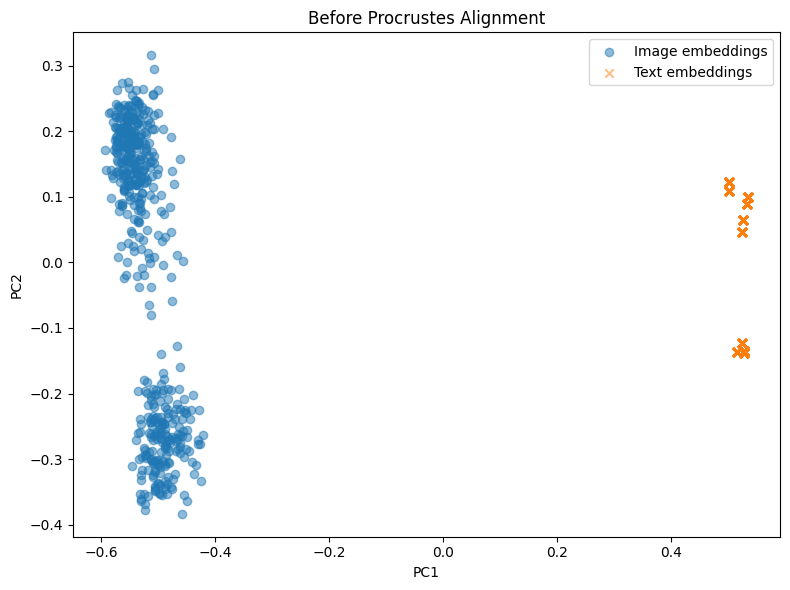

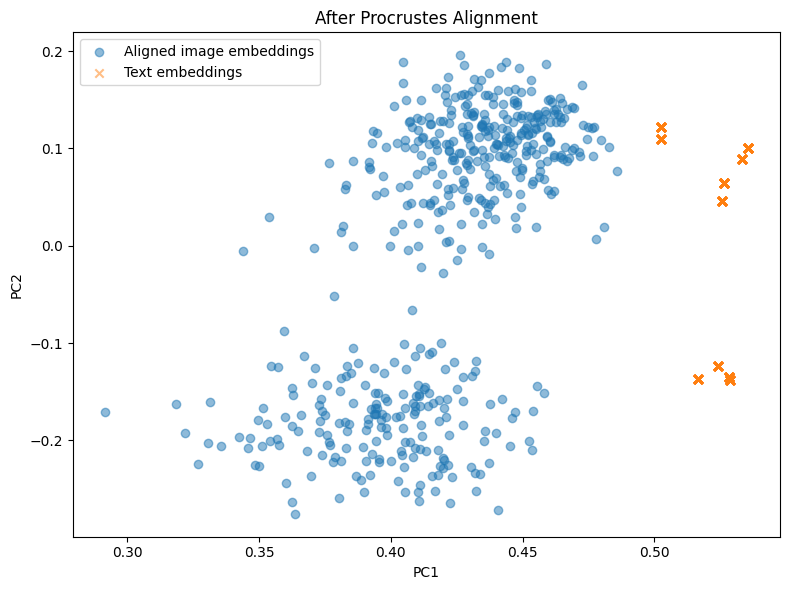

Saved to: task3/results/clip_modality_before_alignment.png
Saved to: task3/results/clip_modality_after_alignment.png


In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    before_images_2d[:, 0],
    before_images_2d[:, 1],
    alpha=0.5,
    label="Image embeddings",
)

plt.scatter(
    before_text_2d[:, 0],
    before_text_2d[:, 1],
    alpha=0.5,
    marker="x",
    label="Text embeddings",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Before Procrustes Alignment")
plt.legend()
plt.tight_layout()

before_alignment_path = (
    RESULTS_DIR
    / "clip_modality_before_alignment.png"
)

plt.savefig(
    before_alignment_path,
    bbox_inches="tight",
)

plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    after_images_2d[:, 0],
    after_images_2d[:, 1],
    alpha=0.5,
    label="Aligned image embeddings",
)

plt.scatter(
    before_text_2d[:, 0],
    before_text_2d[:, 1],
    alpha=0.5,
    marker="x",
    label="Text embeddings",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After Procrustes Alignment")
plt.legend()
plt.tight_layout()

after_alignment_path = (
    RESULTS_DIR
    / "clip_modality_after_alignment.png"
)

plt.savefig(
    after_alignment_path,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved to:",
    before_alignment_path,
)

print(
    "Saved to:",
    after_alignment_path,
)

### Alignment Quality

In [47]:
paired_similarity_before = np.sum(
    gap_image_features
    * gap_text_features,
    axis=1,
)

paired_similarity_after = np.sum(
    aligned_gap_image_features
    * gap_text_features.astype(np.float32),
    axis=1,
)


alignment_quality = pd.DataFrame({
    "condition": [
        "Before alignment",
        "After alignment",
    ],
    "mean_paired_cosine_similarity": [
        paired_similarity_before.mean(),
        paired_similarity_after.mean(),
    ],
    "std_paired_cosine_similarity": [
        paired_similarity_before.std(),
        paired_similarity_after.std(),
    ],
})


print(alignment_quality)


alignment_quality_path = (
    RESULTS_DIR
    / "clip_alignment_quality.csv"
)

alignment_quality.to_csv(
    alignment_quality_path,
    index=False,
)

print(
    "\nSaved to:",
    alignment_quality_path,
)

          condition  mean_paired_cosine_similarity  \
0  Before alignment                       0.266113   
1   After alignment                       0.861984   

   std_paired_cosine_similarity  
0                      0.021133  
1                      0.047955  

Saved to: task3/results/clip_alignment_quality.csv
